# Spicy 1 Transformer Copy Mechanism

This notebook replaces the GRU seq2seq model with a Transformer encoder-decoder and keeps a pointer-generator copy mechanism. The training pipeline is designed to use the full filtered training set by default, while allowing a smaller debug subset through `MAX_TRAIN_SAMPLES`.


In [36]:
import os
from pathlib import Path
import csv
import ast
import math
import random
import time
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import nltk
from nltk.tokenize import word_tokenize

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)
print(f'seed={SEED}')


mps
seed=42


In [37]:
data_dir = Path.cwd() / 'Cooking_Dataset'
if data_dir.exists():
    os.chdir(data_dir)
print(Path.cwd())


/Users/kaichen/Desktop/MONASH/FIT5120/FIT5120-ClimateQuest/AI Development/Cooking_Dataset


In [38]:
PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

SPECIAL_TOKENS = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']

MAX_INPUT_LEN = 80
MAX_OUTPUT_LEN = 160
MIN_FREQ_INPUT = 1
MIN_FREQ_OUTPUT = 1

# Full filtered training set by default. Set to an integer such as 50000 for quick experiments.
MAX_TRAIN_SAMPLES = None
DEV_SAMPLE_SIZE = None

BATCH_SIZE = 32
NUM_WORKERS = 0


In [39]:
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
        self.index2word = {i: tok for i, tok in enumerate(SPECIAL_TOKENS)}
        self.word2count = Counter()
        self.n_words = len(SPECIAL_TOKENS)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.n_words += 1

    def build_from_counter(self, counter, min_freq=1, max_vocab=None):
        kept = 0
        for word, count in counter.most_common():
            if count < min_freq:
                continue
            if max_vocab is not None and kept >= max_vocab:
                break
            self.addWord(word)
            self.word2count[word] = count
            kept += 1


def normalizeRecipeString(s):
    return str(s).lower().strip()


def tokenize_text(text):
    return word_tokenize(normalizeRecipeString(text))


In [40]:
def readRecipePairs(csv_path):
    pairs = []
    with open(csv_path, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                ing_list = ast.literal_eval(row['Ingredients'])
                recipe_steps = ast.literal_eval(row['Recipe'])
                ing_text = ', '.join(str(x) for x in ing_list)
                recipe_text = ' '.join(str(x) for x in recipe_steps).strip()
                pairs.append((ing_text, recipe_text))
            except Exception as exc:
                print('Skip one data row:', exc, row)
    return pairs


def filter_pair(pair):
    input_len = len(tokenize_text(pair[0]))
    output_len = len(tokenize_text(pair[1]))
    return 0 < input_len <= MAX_INPUT_LEN and 0 < output_len <= MAX_OUTPUT_LEN


def filterPairs(pairs):
    return [p for p in pairs if filter_pair(p)]


def maybe_sample_pairs(pairs, max_samples=None):
    if max_samples is None or len(pairs) <= max_samples:
        return pairs
    rng = random.Random(SEED)
    return rng.sample(pairs, max_samples)


def buildLangsFromPairs(train_pairs):
    input_counter = Counter()
    output_counter = Counter()
    for ing, recipe in train_pairs:
        input_counter.update(tokenize_text(ing))
        output_counter.update(tokenize_text(recipe))

    input_lang = Lang('ingredients')
    output_lang = Lang('recipes')
    input_lang.build_from_counter(input_counter, min_freq=MIN_FREQ_INPUT)
    output_lang.build_from_counter(output_counter, min_freq=MIN_FREQ_OUTPUT)
    return input_lang, output_lang


def prepareRecipeData(train_csv='train.csv', dev_csv='dev.csv', test_csv='test.csv'):
    train_pairs = maybe_sample_pairs(filterPairs(readRecipePairs(train_csv)), MAX_TRAIN_SAMPLES)
    dev_pairs = filterPairs(readRecipePairs(dev_csv)) if Path(dev_csv).exists() else []
    test_pairs = filterPairs(readRecipePairs(test_csv)) if Path(test_csv).exists() else []
    dev_pairs = maybe_sample_pairs(dev_pairs, DEV_SAMPLE_SIZE)

    input_lang, output_lang = buildLangsFromPairs(train_pairs)
    print(f'Train samples: {len(train_pairs):,}')
    print(f'Dev samples: {len(dev_pairs):,}')
    print(f'Test samples: {len(test_pairs):,}')
    print(f'Input vocabulary: {input_lang.n_words:,}')
    print(f'Output vocabulary: {output_lang.n_words:,}')
    return input_lang, output_lang, train_pairs, dev_pairs, test_pairs

input_lang, output_lang, train_pairs, dev_pairs, test_pairs = prepareRecipeData()
print(random.choice(train_pairs))


Train samples: 155,248
Dev samples: 1,005
Test samples: 1,043
Input vocabulary: 10,757
Output vocabulary: 15,558
('3 oz. cream cheese, softened, 1 small can crabmeat, seafood cocktail sauce', 'Rinse and drain the crabmeat. Blend cream cheese, crabmeat and cocktail sauce. Chill. Serve with crackers.')


In [41]:
def source_ids(tokens, input_lang):
    return [input_lang.word2index.get(tok, UNK_token) for tok in tokens] + [EOS_token]


def target_input_ids(tokens, output_lang):
    return [SOS_token] + [output_lang.word2index.get(tok, UNK_token) for tok in tokens]


def source_copy_ids(tokens, output_lang):
    """Map source positions into the decoder/extended vocabulary space."""
    oov_list = []
    ids = []
    for tok in tokens:
        if tok in output_lang.word2index:
            ids.append(output_lang.word2index[tok])
        else:
            if tok not in oov_list:
                oov_list.append(tok)
            ids.append(output_lang.n_words + oov_list.index(tok))
    ids.append(EOS_token)
    return ids, oov_list


def target_extended_ids(tokens, output_lang, oov_list):
    ids = []
    for tok in tokens:
        if tok in output_lang.word2index:
            ids.append(output_lang.word2index[tok])
        elif tok in oov_list:
            ids.append(output_lang.n_words + oov_list.index(tok))
        else:
            ids.append(UNK_token)
    ids.append(EOS_token)
    return ids


class RecipeCopyDataset(Dataset):
    def __init__(self, pairs, input_lang, output_lang):
        self.examples = []
        for ing, recipe in pairs:
            src_tokens = tokenize_text(ing)
            tgt_tokens = tokenize_text(recipe)
            src = source_ids(src_tokens, input_lang)
            src_copy, oov = source_copy_ids(src_tokens, output_lang)
            tgt_in = target_input_ids(tgt_tokens, output_lang)
            tgt_out = target_extended_ids(tgt_tokens, output_lang, oov)
            self.examples.append({
                'src': src,
                'src_copy': src_copy,
                'tgt_in': tgt_in,
                'tgt_out': tgt_out,
                'oov': oov,
                'ingredients': ing,
                'recipe': recipe,
            })

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]


def pad_2d(seqs, pad_value=PAD_token):
    max_len = max(len(s) for s in seqs)
    out = torch.full((len(seqs), max_len), pad_value, dtype=torch.long)
    for i, seq in enumerate(seqs):
        out[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)
    return out


def collate_recipe_batch(batch):
    src = pad_2d([x['src'] for x in batch])
    src_copy = pad_2d([x['src_copy'] for x in batch])
    tgt_in = pad_2d([x['tgt_in'] for x in batch])
    tgt_out = pad_2d([x['tgt_out'] for x in batch])
    max_oov = max(len(x['oov']) for x in batch)
    return {
        'src': src,
        'src_copy': src_copy,
        'tgt_in': tgt_in,
        'tgt_out': tgt_out,
        'extended_vocab_size': output_lang.n_words + max_oov,
        'oov': [x['oov'] for x in batch],
        'ingredients': [x['ingredients'] for x in batch],
        'recipe': [x['recipe'] for x in batch],
    }

train_dataset = RecipeCopyDataset(train_pairs, input_lang, output_lang)
dev_dataset = RecipeCopyDataset(dev_pairs, input_lang, output_lang) if dev_pairs else None
test_dataset = RecipeCopyDataset(test_pairs, input_lang, output_lang) if test_pairs else None

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_recipe_batch, num_workers=NUM_WORKERS)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_recipe_batch, num_workers=NUM_WORKERS) if dev_dataset else None
print(f'Train batches: {len(train_loader):,}')


Train batches: 4,852


In [42]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=2048):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class CopyTransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None, memory_key_padding_mask=None):
        self_out, _ = self.self_attn(
            tgt, tgt, tgt,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
            need_weights=False,
        )
        tgt = self.norm1(tgt + self.dropout1(self_out))
        cross_out, cross_weights = self.cross_attn(
            tgt, memory, memory,
            key_padding_mask=memory_key_padding_mask,
            need_weights=True,
            average_attn_weights=False,
        )
        tgt = self.norm2(tgt + self.dropout2(cross_out))
        ff = self.linear2(self.dropout(F.gelu(self.linear1(tgt))))
        tgt = self.norm3(tgt + self.dropout3(ff))
        return tgt, cross_weights


class TransformerPointerGenerator(nn.Module):
    def __init__(self, input_vocab_size, output_vocab_size, d_model=256, nhead=8, num_encoder_layers=3,
                 num_decoder_layers=3, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.output_vocab_size = output_vocab_size
        self.d_model = d_model
        self.src_embedding = nn.Embedding(input_vocab_size, d_model, padding_idx=PAD_token)
        self.tgt_embedding = nn.Embedding(output_vocab_size, d_model, padding_idx=PAD_token)
        self.positional = PositionalEncoding(d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers, enable_nested_tensor=False)
        self.decoder_layers = nn.ModuleList([
            CopyTransformerDecoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_decoder_layers)
        ])
        self.vocab_proj = nn.Linear(d_model, output_vocab_size)
        self.p_gen_proj = nn.Linear(d_model * 3, 1)

    def forward(self, src, tgt_in, src_copy_ids, extended_vocab_size):
        src_padding = src.eq(PAD_token)
        tgt_padding = tgt_in.eq(PAD_token)
        tgt_mask = torch.triu(
            torch.ones(tgt_in.size(1), tgt_in.size(1), dtype=torch.bool, device=tgt_in.device),
            diagonal=1,
        )

        src_emb = self.positional(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional(self.tgt_embedding(tgt_in) * math.sqrt(self.d_model))
        memory = self.encoder(src_emb, src_key_padding_mask=src_padding)

        dec = tgt_emb
        cross_weights = None
        for layer in self.decoder_layers:
            dec, cross_weights = layer(
                dec,
                memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=tgt_padding,
                memory_key_padding_mask=src_padding,
            )

        vocab_dist = F.softmax(self.vocab_proj(dec), dim=-1)
        if extended_vocab_size > self.output_vocab_size:
            extra = torch.zeros(
                vocab_dist.size(0),
                vocab_dist.size(1),
                extended_vocab_size - self.output_vocab_size,
                device=vocab_dist.device,
                dtype=vocab_dist.dtype,
            )
            vocab_dist = torch.cat([vocab_dist, extra], dim=-1)

        attn = cross_weights.mean(dim=1)  # [batch, tgt_len, src_len]
        attn = attn.masked_fill(src_padding.unsqueeze(1), 0.0)
        attn = attn / attn.sum(dim=-1, keepdim=True).clamp_min(1e-12)
        context = torch.bmm(attn, memory)

        p_gen = torch.sigmoid(self.p_gen_proj(torch.cat([dec, context, tgt_emb], dim=-1)))
        copy_dist = torch.zeros_like(vocab_dist)
        scatter_index = src_copy_ids.unsqueeze(1).expand(-1, tgt_in.size(1), -1)
        copy_dist.scatter_add_(dim=-1, index=scatter_index, src=attn)
        final_dist = p_gen * vocab_dist + (1 - p_gen) * copy_dist
        return final_dist.clamp_min(1e-12), p_gen, attn


In [43]:
def masked_nll_loss(final_dist, target_ext_ids):
    gold_probs = final_dist.gather(dim=-1, index=target_ext_ids.unsqueeze(-1)).squeeze(-1)
    mask = target_ext_ids.ne(PAD_token)
    loss = -torch.log(gold_probs.clamp_min(1e-12))
    return loss.masked_select(mask).mean()


def move_batch_to_device(batch):
    out = dict(batch)
    for key in ['src', 'src_copy', 'tgt_in', 'tgt_out']:
        out[key] = batch[key].to(device)
    return out


def train_one_epoch(model, loader, optimizer, scheduler=None, grad_clip=1.0, print_every=100):
    model.train()
    total_loss = 0.0
    start = time.time()
    for step, raw_batch in enumerate(loader, 1):
        batch = move_batch_to_device(raw_batch)
        optimizer.zero_grad(set_to_none=True)
        final_dist, _, _ = model(batch['src'], batch['tgt_in'], batch['src_copy'], batch['extended_vocab_size'])
        loss = masked_nll_loss(final_dist, batch['tgt_out'])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item()
        if step % print_every == 0:
            elapsed = time.time() - start
            print(f'step {step:>5}/{len(loader):<5} loss={total_loss/step:.4f} elapsed={elapsed/60:.1f}m')
    return total_loss / max(1, len(loader))


@torch.no_grad()
def evaluate_loss(model, loader):
    if loader is None:
        return None
    model.eval()
    total_loss = 0.0
    for raw_batch in loader:
        batch = move_batch_to_device(raw_batch)
        final_dist, _, _ = model(batch['src'], batch['tgt_in'], batch['src_copy'], batch['extended_vocab_size'])
        total_loss += masked_nll_loss(final_dist, batch['tgt_out']).item()
    return total_loss / max(1, len(loader))


In [44]:
CHECKPOINT_PATH = 'best_spicy1_transformer_copy.pt'

model = TransformerPointerGenerator(
    input_vocab_size=input_lang.n_words,
    output_vocab_size=output_lang.n_words,
    d_model=256,
    nhead=8,
    num_encoder_layers=3,
    num_decoder_layers=3,
    dim_feedforward=1024,
    dropout=0.15,
).to(device)

EPOCHS = 12
LEARNING_RATE = 3e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
total_steps = max(1, EPOCHS * len(train_loader))
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    total_steps=total_steps,
    pct_start=0.08,
    anneal_strategy='cos',
)

def export_lang_state(lang):
    return {
        'name': lang.name,
        'word2index': lang.word2index,
        'index2word': lang.index2word,
        'word2count': dict(lang.word2count),
        'n_words': lang.n_words,
    }


def save_checkpoint(path, model, input_lang, output_lang, best_dev_loss, epoch):
    torch.save({
        'model_state_dict': model.state_dict(),
        'input_lang': export_lang_state(input_lang),
        'output_lang': export_lang_state(output_lang),
        'best_dev_loss': best_dev_loss,
        'epoch': epoch,
        'config': {
            'd_model': model.d_model,
            'output_vocab_size': model.output_vocab_size,
        },
    }, path)

best_dev_loss = float('inf')
train_losses = []
dev_losses = []

for epoch in range(1, EPOCHS + 1):
    print(f'\nEpoch {epoch}/{EPOCHS}')
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler=scheduler, print_every=100)
    dev_loss = evaluate_loss(model, dev_loader)
    train_losses.append(train_loss)
    dev_losses.append(dev_loss)
    print(f'epoch={epoch} train_loss={train_loss:.4f} dev_loss={dev_loss if dev_loss is not None else float("nan"):.4f}')
    if dev_loss is not None and dev_loss < best_dev_loss:
        best_dev_loss = dev_loss
        save_checkpoint(CHECKPOINT_PATH, model, input_lang, output_lang, best_dev_loss, epoch)
        print(f'Saved best checkpoint to {CHECKPOINT_PATH}')



Epoch 1/12
step   100/4852  loss=9.7930 elapsed=1.3m
step   200/4852  loss=8.9820 elapsed=2.0m
step   300/4852  loss=8.4059 elapsed=2.6m
step   400/4852  loss=7.9352 elapsed=5.7m
step   500/4852  loss=7.5467 elapsed=8.0m
step   600/4852  loss=7.2259 elapsed=9.9m
step   700/4852  loss=6.9529 elapsed=12.1m


KeyboardInterrupt: 

In [ ]:
def decode_token(token_id, output_lang, oov_list):
    if token_id < output_lang.n_words:
        return output_lang.index2word.get(token_id, '<UNK>')
    idx = token_id - output_lang.n_words
    if 0 <= idx < len(oov_list):
        return oov_list[idx]
    return '<UNK>'


@torch.no_grad()
def generate_recipe(model, ingredient_text, max_len=MAX_OUTPUT_LEN, min_len=8, temperature=0.9, top_k=10):
    model.eval()
    src_tokens = tokenize_text(ingredient_text)
    src = source_ids(src_tokens, input_lang)
    src_copy, oov_list = source_copy_ids(src_tokens, output_lang)
    src_tensor = torch.tensor([src], dtype=torch.long, device=device)
    src_copy_tensor = torch.tensor([src_copy], dtype=torch.long, device=device)
    generated = [SOS_token]
    words = []
    extended_vocab_size = output_lang.n_words + len(oov_list)

    for _ in range(max_len):
        decoder_input_ids = [tok if tok < output_lang.n_words else UNK_token for tok in generated]
        tgt_in = torch.tensor([decoder_input_ids], dtype=torch.long, device=device)
        final_dist, _, _ = model(src_tensor, tgt_in, src_copy_tensor, extended_vocab_size)
        probs = final_dist[0, -1].clone()
        probs[PAD_token] = 0
        probs[SOS_token] = 0
        if len(words) < min_len:
            probs[EOS_token] = 0
        if words:
            last_id = generated[-1]
            if last_id < probs.numel():
                probs[last_id] *= 0.35
        if top_k and top_k < probs.numel():
            keep = torch.topk(probs, top_k).indices
            masked = torch.zeros_like(probs)
            masked[keep] = probs[keep]
            probs = masked
        probs = torch.pow(probs.clamp_min(1e-12), 1 / max(temperature, 1e-6))
        probs = probs / probs.sum()
        token_id = torch.multinomial(probs, 1).item()
        generated.append(token_id)
        if token_id == EOS_token:
            break
        word = decode_token(token_id, output_lang, oov_list)
        if word not in SPECIAL_TOKENS:
            words.append(word)
    return ' '.join(words)


def evaluateRandomly(model, n=5):
    for _ in range(n):
        ing, gold = random.choice(dev_pairs if dev_pairs else train_pairs)
        print('> Ingredients:', ing)
        print('= Target:', gold)
        print('< Output:', generate_recipe(model, ing))
        print('-' * 80)

evaluateRandomly(model, n=5)


> Ingredients: 2 c. water, 1/2 bunch celery, 1 bunch parsley, 1 large onion, 1/2 stick margarine, 2 Tbsp. vinegar, 4 Tbsp. lemon juice, 1/2 Tbsp. dry mustard, 4 lb. roast or more, 2 Tbsp. brown sugar, 2 Tbsp. Worcestershire sauce, 1 large catsup, 1 bottle chili sauce
= Target: Cook meat the night before. Cook water, celery and parsley together for 20 minutes. Strain it and save the juice. Saute 1 large onion (cut small) in margarine. Add in remaining ingredients plus shredded beef. Cook until warmed through, about 45 minutes over medium heat, stirring frequently.
< Output: add water and cook for 1 cup of ingredients . pour over medium heat to taste .
--------------------------------------------------------------------------------
> Ingredients: 1/2 gal. water, 4 Tbsp. sugar, 1 gal. cider, 3 qt. water, 3 small cans orange juice, 4 small cans lemonade, 1/2 can pumpkin pie spice
= Target: Boil 1/2 gallon water and sugar until sugar has dissolved. Add remaining ingredients and heat until v

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 59.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 59.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


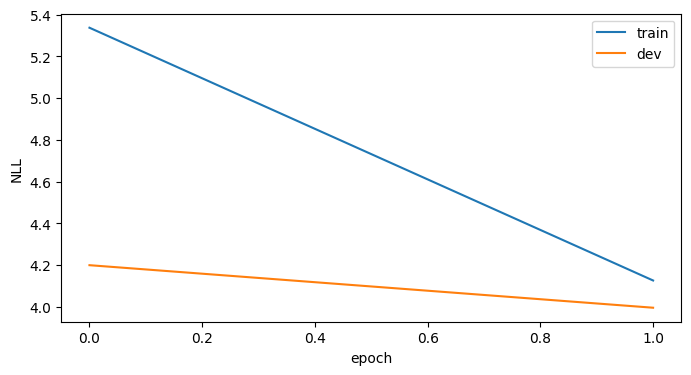

In [ ]:
%pip install matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train')
if any(x is not None for x in dev_losses):
    plt.plot(dev_losses, label='dev')
plt.xlabel('epoch')
plt.ylabel('NLL')
plt.legend()
plt.show()


In [ ]:
%pip install bert_score


  Using cached bert_score-0.3.13-py3-none-any.whl.metadata (15 kB)
Using cached bert_score-0.3.13-py3-none-any.whl (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 67.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 71.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 43.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 49.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 79.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 77.7 MB/s  0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0━━━━━  0/19 [sympy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19/19 [bert_score]9 [transformers]y]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from bert_score import score

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
    nltk.download('omw-1.4')


def compute_metrics(ref, hyp):
    ref_tokens = tokenize_text(ref)
    hyp_tokens = tokenize_text(hyp)
    smoothie = SmoothingFunction().method4
    bleu4 = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
    meteor = meteor_score([ref_tokens], hyp_tokens)
    return bleu4, meteor


def evaluate_on_dataset(model, data_pairs, max_items=None):
    eval_pairs = data_pairs if max_items is None else data_pairs[:max_items]
    total_bleu = 0.0
    total_meteor = 0.0
    all_preds = []
    all_golds = []
    for i, (ing, gold) in enumerate(eval_pairs, 1):
        pred = generate_recipe(model, ing, temperature=0.8, top_k=8)
        bleu, meteor = compute_metrics(gold, pred)
        total_bleu += bleu
        total_meteor += meteor
        all_preds.append(pred)
        all_golds.append(gold)
        if i % 100 == 0:
            print(f'evaluated {i}/{len(eval_pairs)}')

    mean_bleu = total_bleu / max(1, len(eval_pairs))
    mean_meteor = total_meteor / max(1, len(eval_pairs))
    P, R, F1 = score(all_preds, all_golds, lang='en', verbose=False)
    mean_bert = F1.mean().item()
    print(f'Average BLEU-4: {mean_bleu:.4f}')
    print(f'Average METEOR: {mean_meteor:.4f}')
    print(f'Average BERTScore F1: {mean_bert:.4f}')
    return mean_bleu, mean_meteor, mean_bert

# Full BERTScore can be slow. Start with a subset, then run full test when ready.
evaluate_on_dataset(model, test_pairs, max_items=500)


/opt/anaconda3/envs/insane-cook/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to /Users/kaichen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/kaichen/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


evaluated 100/500
evaluated 200/500
evaluated 300/500
evaluated 400/500
evaluated 500/500


/opt/anaconda3/envs/insane-cook/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/insane-cook/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/anaconda3/envs/insane-cook/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/envs/insane-cook/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/insane-cook/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/insane-cook/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/insane-cook/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your e

Average BLEU-4: 0.0248
Average METEOR: 0.1513
Average BERTScore F1: 0.8357


(0.024834936762843828, 0.1512818059896256, 0.8357172012329102)

In [ ]:
def export_predictions(model, pairs, output_path='test_with_preds_transformer_copy.tsv'):
    with open(output_path, 'w', encoding='utf-8', newline='') as f:
        writer = csv.writer(f, delimiter='\t')
        writer.writerow(['Ingredients', 'GeneratedRecipe'])
        for ing, _ in pairs:
            writer.writerow([ing, generate_recipe(model, ing, temperature=0.8, top_k=8)])
    print('Done. Output saved at:', output_path)

export_predictions(model, test_pairs)


Done. Output saved at: test_with_preds_transformer_copy.tsv
